# Schofield–Zhu 2D Phase Unwrapping

This notebook implements a 2D phase-unwrapping method based on the Schofield–Zhu Fourier algorithm, based on the paper below. It is used for interferometric and holography data where the phase is wrapped within the interval $[-\pi, \pi)$, and the goal is to recover the continuous phase.

Ref: Schofield M A and Zhu Y 2003 Fast phase unwrapping algorithm for interferometric applications Opt. Lett.

## Purpose
A wrapped phase image contains discontinuities at values near $\pm \pi$, because phase is only known modulo $2\pi$. The goal of phase unwrapping is to reconstruct the continuous phase by correcting these jumps.

The method used here is based on the relationship between the wrapped phase and its Laplacian. Instead of using a local finite-difference method, the algorithm performs the calculation in the Fourier domain, which is often more stable and efficient for smooth phase fields.

## Key ideas
- The image is first extended by mirror symmetry to reduce boundary effects.
- The Laplacian is computed using Fourier differentiation.
- The phase is estimated by solving a Laplace-type equation in the frequency domain.
- Integer multiples of $2\pi$ are added or subtracted to recover the correct unwrapped phase.
- The final result is cropped back to the original image size.

## Author and date
- Author: Ebrahim Chalangar
- Institution: Denmark Technical University, DTU Nanolab
- Email: ebrahim.chalangar@gmail.com
- Date: 2026-09-10

## Overview of the code
The first function, `_mirror_symmetrize`, creates a larger image by reflecting the original data both horizontally and vertically. This produces a mirrored extension that reduces artificial boundary effects and improves the accuracy of Fourier-based differentiation.

The function `_spectral_laplacian` computes the 2D Laplacian using Fourier transforms instead of finite differences. In the Fourier domain, derivatives become multiplication by frequency values. The code creates frequency grids using `np.fft.fftfreq`, forms the squared wave-number term $k_x^2 + k_y^2$, multiplies the FFT of the image by $-(k_x^2 + k_y^2)$, and then applies the inverse FFT to recover the Laplacian.

The function `_inverse_spectral_laplacian` solves the equation $\nabla^2 \phi = \text{image}$ in the Fourier domain. Since the zero-frequency component corresponds to the undefined mean offset, the code sets the DC term to zero. This is physically reasonable because phase unwrapping cannot determine an arbitrary global phase offset.

The main function, `schofield_zhu_unwrap_2d`, validates the input, normalizes the wrapped phase into the principal range $[-\pi, \pi)$, extends the image by mirroring, and computes the Laplacian of the wrapped phase using the Fourier method. It then estimates the unwrapped phase and iteratively corrects it by integer multiples of $2\pi$ until the phase is consistent.

The update step is:

$$
\text{integer\_correction} = \mathrm{rint}\left(\frac{\text{phase\_estimate} - \text{current\_phase}}{2\pi}\right)
$$

and then the phase is updated by:

$$
\text{next\_phase} = \text{current\_phase} + 2\pi \times \text{integer\_correction}
$$

This works because wrapped phase values differ only by integer multiples of $2\pi$.

After convergence, the algorithm crops the mirrored region back to the original image size and optionally removes the mean value if `center_result=True`.

## Example comparison
The final code block compares the custom Schofield–Zhu unwrapping result with the output from `skimage`'s `unwrap_phase`. It creates a synthetic wrapped phase image from a grayscale input, unwraps it using both methods, and then displays a visual comparison of the original, wrapped, and reconstructed data. This helps confirm that the method is functioning correctly in practice.

This notebook is useful for understanding how Fourier-based phase unwrapping works and how it can be applied to experimental data in fields such as holography and interferometry.


In [1]:
"""
Author: Ebrahim Chalangar
Institution: Denmark Technical University, DTU Nanolab
Email: ebrahim.chalangar@gmail.com
Date: 2026-09-10
"""
import numpy as np


def _mirror_symmetrize(image):
    """
    Construct a 2Ny x 2Nx even-symmetric extension.

    Original image:
        A

    Extended image:
        A              mirror_x(A)
        mirror_y(A)    mirror_xy(A)
    """
    extended_x = np.concatenate((image, image[:, ::-1]), axis=1)

    extended_xy = np.concatenate((extended_x, extended_x[::-1, :]), axis=0)

    return extended_xy


def _spectral_laplacian(image):
    """
    Calculate the 2D Laplacian using Fourier differentiation.
    """
    ny, nx = image.shape

    ky = 2.0 * np.pi * np.fft.fftfreq(ny)
    kx = 2.0 * np.pi * np.fft.fftfreq(nx)

    kx_grid, ky_grid = np.meshgrid(kx, ky)

    k_squared = kx_grid**2 + ky_grid**2

    image_fft = np.fft.fft2(image)

    laplacian_fft = -k_squared * image_fft

    return np.fft.ifft2(laplacian_fft).real


def _inverse_spectral_laplacian(image):
    """
    Solve Laplacian(solution) = image using Fourier methods.

    The zero-frequency component is set to zero because the
    absolute phase offset cannot be determined by phase unwrapping.
    """
    ny, nx = image.shape

    ky = 2.0 * np.pi * np.fft.fftfreq(ny)
    kx = 2.0 * np.pi * np.fft.fftfreq(nx)

    kx_grid, ky_grid = np.meshgrid(kx, ky)

    k_squared = kx_grid**2 + ky_grid**2

    image_fft = np.fft.fft2(image)

    solution_fft = np.zeros_like(image_fft, dtype=np.complex128)

    nonzero = k_squared > 0

    solution_fft[nonzero] = -image_fft[nonzero] / k_squared[nonzero]

    # Arbitrary mean phase offset
    solution_fft[0, 0] = 0.0

    return np.fft.ifft2(solution_fft).real


def schofield_zhu_unwrap_2d(
    wrapped_phase,
    max_iterations=10,
    tolerance=0.0,
    center_result=False,
):
    """
    Unwrap one 2D phase image using the Schofield-Zhu algorithm.
    ref:Schofield M A and Zhu Y 2003 Fast phase unwrapping algorithm for interferometric applications Opt. Lett.

    Parameters
    ----------
    wrapped_phase : array-like
        Wrapped phase image in radians. Expected range is normally
        [-pi, pi), although values are wrapped internally.
    max_iterations : int, default 10
        Maximum number of integer-correction iterations.
    tolerance : float, default 0.0
        Stop when the maximum absolute phase change is less than or
        equal to this value. Because the corrections are multiples
        of 2*pi, zero is normally appropriate.
    center_result : bool, default False
        If True, subtract the mean of the final unwrapped phase.

    Returns
    -------
    unwrapped : ndarray
        Unwrapped 2D phase image.
    """
    wrapped_phase = np.asarray(wrapped_phase, dtype=np.float64)

    if wrapped_phase.ndim != 2:
        raise ValueError("The input to schofield_zhu_unwrap_2d must be a 2D array.")

    if not np.all(np.isfinite(wrapped_phase)):
        raise ValueError(
            "The wrapped phase contains NaN or infinite values. "
            "Mask, crop, or fill these pixels before unwrapping."
        )

    ny, nx = wrapped_phase.shape

    # Put the input explicitly in the principal interval [-pi, pi)
    wrapped_phase = (wrapped_phase + np.pi) % (2.0 * np.pi) - np.pi

    # Mirror extension approximates a zero-normal-gradient boundary
    wrapped_extended = _mirror_symmetrize(wrapped_phase)

    sin_phase = np.sin(wrapped_extended)
    cos_phase = np.cos(wrapped_extended)

    # From:
    # Laplacian(phi) =
    # cos(phi_w) Laplacian(sin(phi_w))
    # - sin(phi_w) Laplacian(cos(phi_w))
    laplacian_true_phase = cos_phase * _spectral_laplacian(
        sin_phase
    ) - sin_phase * _spectral_laplacian(cos_phase)

    # phi_0 in the paper: a Fourier estimate of the unwrapped phase
    phase_estimate = _inverse_spectral_laplacian(laplacian_true_phase)

    current_phase = wrapped_extended.copy()

    for iterate in range(max_iterations):
        integer_correction = np.rint((phase_estimate - current_phase) / (2.0 * np.pi))

        next_phase = current_phase + 2.0 * np.pi * integer_correction

        maximum_change = np.max(np.abs(next_phase - current_phase))

        current_phase = next_phase

        print(
            f"Iteration {iterate + 1}: "
            f"maximum absolute phase change = {maximum_change:.6f}"
        )
        if maximum_change <= tolerance:
            break

    # Extract the quadrant corresponding to the original phase image
    unwrapped = current_phase[:ny, :nx]

    if center_result:
        unwrapped = unwrapped - np.mean(unwrapped)

    return unwrapped

Iteration 1: maximum absolute phase change = 6.283185
Iteration 2: maximum absolute phase change = 0.000000


Text(0.5, 1.0, 'Unwrapped - original')

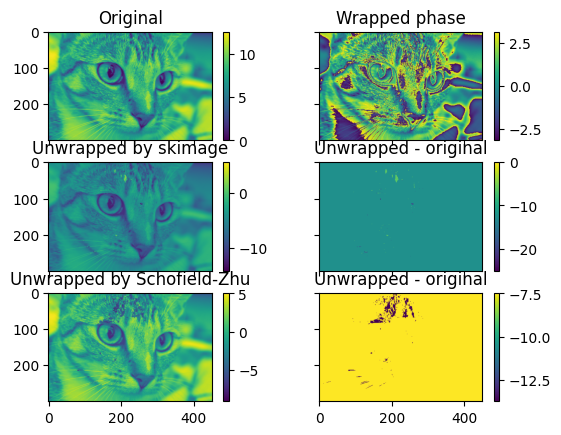

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from skimage import data, img_as_float, color, exposure
from skimage.restoration import unwrap_phase

# Load an image as a floating-point grayscale
image = color.rgb2gray(img_as_float(data.chelsea()))
# Scale the image to [0, 4*pi]
image = exposure.rescale_intensity(image, out_range=(0, 4 * np.pi))
# Create a phase-wrapped image in the interval [-pi, pi)
image_wrapped = np.angle(np.exp(1j * image))
# Perform phase unwrapping by skimage's unwrap_phase function
image_unwrapped_skimage = unwrap_phase(image_wrapped)

# Perform phase unwrapping by Schofield-Zhu algorithm
image_unwrapped_schofield_zhu = schofield_zhu_unwrap_2d(image_wrapped,center_result=True)

fig, ax = plt.subplots(3, 2, sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = ax.ravel()

fig.colorbar(ax1.imshow(image, vmin=0, vmax=4 * np.pi), ax=ax1)
ax1.set_title("Original")

fig.colorbar(ax2.imshow(image_wrapped, vmin=-np.pi, vmax=np.pi), ax=ax2)
ax2.set_title("Wrapped phase")

fig.colorbar(ax3.imshow(image_unwrapped_skimage), ax=ax3)
ax3.set_title("Unwrapped by skimage")

fig.colorbar(ax4.imshow(image_unwrapped_skimage - image), ax=ax4)
ax4.set_title("Unwrapped - original")

fig.colorbar(ax5.imshow(image_unwrapped_schofield_zhu), ax=ax5)
ax5.set_title("Unwrapped by Schofield-Zhu")

fig.colorbar(ax6.imshow(image_unwrapped_schofield_zhu - image), ax=ax6)
ax6.set_title("Unwrapped - original")